In [26]:

from sklearn import set_config
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
import seaborn as sns
import joblib
import json
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score, recall_score, roc_curve, precision_score, auc
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import chi2_contingency
import pickle
import os
os.chdir(r"C:\Users\angel\Desktop\Proyectos_privados\PROYECTOS\EasyMoney_Capstone")

pd.set_option('display.max_columns', None)
from src.utils import *
set_config(transform_output="pandas")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)


In [27]:
target = "sales_account"

val_df = pd.read_csv(
    "data/processed/output_data_enriquesida_muestra_limpia_validacion.csv",  sep="|", low_memory=False)

val_df_X = val_df.drop(target, axis=1)
val_df_y = val_df[[target]]


In [28]:
df = pd.read_csv("results/metrics/model_metrics.csv",
                 sep=",", low_memory=False)


In [29]:
df[(df["METRICA"]=="ROC_AUC") & (df["PROCESO"]=="TEST")]

,Nombre_Modelo,timestamp,PROCESO,METRICA,VALOR,Comentario
9,LogisticRegression,2026-03-15 20:37:08,TEST,ROC_AUC,0.8770,modelo Base
24,DecisionTreeClassifier,2026-03-16 23:30:19,TEST,ROC_AUC,0.9340,"{'max_depth': 15, 'min_samples_leaf': 10, 'min..."
39,XGBClassifier,2026-03-17 21:27:54,TEST,ROC_AUC,0.9480,"{'max_depth': 10, 'n_estimators': 400}"
54,RandomForestClassifier,2026-03-17 22:53:01,TEST,ROC_AUC,0.9410,"{'max_depth': 15, 'min_samples_leaf': 20}"


In [30]:
df[(df["METRICA"]=="F1") & (df["PROCESO"]=="TEST")]

,Nombre_Modelo,timestamp,PROCESO,METRICA,VALOR,Comentario
8,LogisticRegression,2026-03-15 20:37:08,TEST,F1,0.5160,modelo Base
23,DecisionTreeClassifier,2026-03-16 23:30:19,TEST,F1,0.7320,"{'max_depth': 15, 'min_samples_leaf': 10, 'min..."
38,XGBClassifier,2026-03-17 21:27:54,TEST,F1,0.7450,"{'max_depth': 10, 'n_estimators': 400}"
53,RandomForestClassifier,2026-03-17 22:53:01,TEST,F1,0.6790,"{'max_depth': 15, 'min_samples_leaf': 20}"


In [35]:

def plot_roc_models(models, X_test, y_test):

    plt.figure(figsize=(8, 6))

    for name, model in models:

        # Probabilidades
        y_prob = model.predict_proba(X_test)[:, 1]

        # Curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        # Plot
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    # Línea diagonal
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Comparación de Modelos")
    plt.legend()
    plt.savefig(f"results/plots/roc_curve_models.png", dpi=300)
    plt.grid()

    plt.show()


In [32]:
with open(f"results/model/fit_model/LogisticRegression.pkl", "rb") as f:
    model_logistic = pickle.load(f)

with open(f"results/model/fit_model/DecisionTreeClassifier.pkl", "rb") as f:
    model_dtc = pickle.load(f)

with open(f"results/model/fit_model/RandomForestClassifier.pkl", "rb") as f:
    model_rf = pickle.load(f)

with open(f"results/model/fit_model/XGBClassifier.pkl", "rb") as f:
    model_xgb = pickle.load(f)


In [33]:
models = [
    ("Logistic Regression", model_logistic),
    ("Decision TreeClassifier", model_dtc),
    ("Random Forest", model_rf),
    ("XGBoost", model_xgb)
]


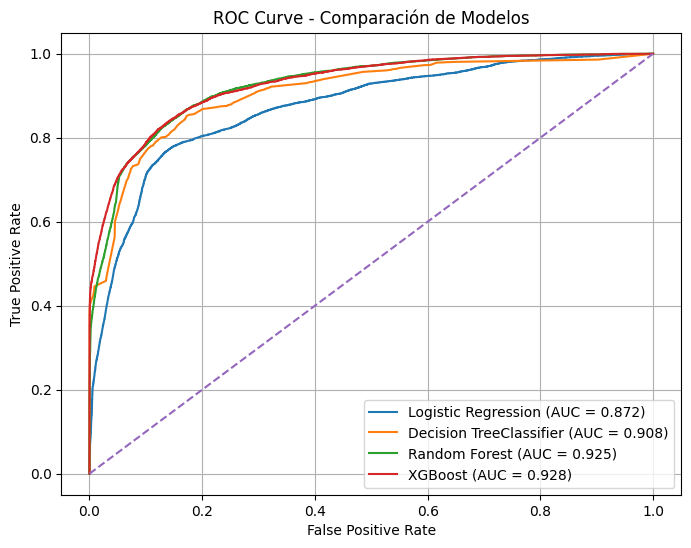

In [36]:
plot_roc_models(models, val_df_X, val_df_y)


In [4]:
df

,Nombre_Modelo,timestamp,PROCESO,METRICA,VALOR,Comentario
0,LogisticRegression,2026-03-15 20:37:08,TRAIN,Accuracy,0.8780,modelo Base
1,LogisticRegression,2026-03-15 20:37:08,TRAIN,Precision,0.6900,modelo Base
2,LogisticRegression,2026-03-15 20:37:08,TRAIN,Recall,0.4110,modelo Base
3,LogisticRegression,2026-03-15 20:37:08,TRAIN,F1,0.5160,modelo Base
4,LogisticRegression,2026-03-15 20:37:08,TRAIN,ROC_AUC,0.8740,modelo Base
5,LogisticRegression,2026-03-15 20:37:08,TEST,Accuracy,0.8780,modelo Base
6,LogisticRegression,2026-03-15 20:37:08,TEST,Precision,0.6800,modelo Base
7,LogisticRegression,2026-03-15 20:37:08,TEST,Recall,0.4160,modelo Base
8,LogisticRegression,2026-03-15 20:37:08,TEST,F1,0.5160,modelo Base
9,LogisticRegression,2026-03-15 20:37:08,TEST,ROC_AUC,0.8770,modelo Base


In [ ]:
jupytext --to py:light notebooks\06_eleccion_model.ipynb --output src\06_eleccion_model.py

In [ ]:
jupytext --to py:light notebooks\07_train_model.ipynb --output src\07_train_model.py

In [1]:
print("1")

1
